# Forecasts against modified gravity

Peculiar-velocity forecasts (ZTF, LSST) and spectroscopic growth-rate forecasts
(Euclid, DESI), on a logarithmic redshift axis, against modified-gravity
predictions.

**The model curves are EFTCAMB runs**, exported by
`notebooks/eftcamb_theory.ipynb` (or `growth-review-eftcamb-export`) on a machine
with a compiled H-EFTCAMB and copied into `growth_review/data/theory/`. Nothing in
this package approximates them. Without those exports the forecast panels below
still build — the surveys are the data, and they do not depend on any model — but
the comparison sections have nothing to compare against and say so. The one model
of the source notebook that is *not* an EFTCAMB run there either is nDGP: DGP has
no EFTCAMB mapping (see §3.5 of `EFTCAMB_fsigma8.ipynb`), so it is absent here
too.

The question the notebook is built around is not "what will $f\sigma_8(z)$ look
like" — a forecast has no central value, so it says nothing about that. It is:
**which of these surveys can tell a given modified-gravity model from
$\Lambda$CDM, and at what redshift does each one do it?** That comparison is a
ratio of two per-cent numbers: the projected precision $\sigma_{f\sigma_8}/f\sigma_8$
in a bin, against the model's deviation from $\Lambda$CDM at that redshift.

Why a log redshift axis: the peculiar-velocity forecasts live at $z \simeq 0.05$
and the spectroscopic ones at $0.7 < z < 2$, a factor of 40 apart. On a linear
axis the entire PV set collapses into the first 3% of the panel. The cost of the
log axis is that $z = 0$ cannot be drawn — no forecast bin here sits at exactly
zero, so nothing is lost.

**Forecasts are not measurements.** Every bar below is drawn *around the fiducial
$\Lambda$CDM curve*, because that is the only place a projected uncertainty can be
put. Read as data, a forecast bar says the model has been confirmed at that
precision, which is exactly backwards.

## 1. Setup, and the four forecast programmes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import growth_review as gr
from growth_review import theory as th

gr.use_style()

fc = gr.load_fsigma8(kind="forecast")
print(fc.groupby(["dataset", "ref"]).size().to_string())

dataset                        ref                      
bao_rsd_desi                   DESI design (ELG/LRG/QSO)    13
bao_rsd_desi_bgs               DESI design (BGS)             5
fsigma8_4most_bgs_howlett2017  Howlett+17 4MOST BGS         10
fsigma8_euclid                 Euclid                       14
fsigma8_sn_pv                  LSST_Full                     5
                               LSST_Photo-typed              5
                               LSST_Specz                    5
                               ZTF                           1
fsigma8_sn_pv_howlett2017      Howlett+17 SN-PV             10


The peculiar-velocity forecasts come as several configurations of the same
survey, and the LSST redshift ranges are **nested** — $[0.02, 0.10]$ and
$[0.02, 0.14]$ contain $[0.02, 0.06]$, and so on. Averaging or stacking them
would use the same supernovae several times, so two views are taken below:

* the three **disjoint** bins $[0.02,0.06]$, $[0.06,0.10]$, $[0.10,0.14]$, which
  can be combined;
* the single widest bin $[0.02,0.14]$, which is the headline number.

In [2]:
sn = fc[fc["dataset"] == "fsigma8_sn_pv"]
print(sn[["ref", "label", "z", "frac_err"]].to_string(index=False))

             ref                         label     z  frac_err
             ZTF              ZTF [0.02, 0.06] 0.045      0.19
       LSST_Full        LSST_Full [0.02, 0.06] 0.050      0.14
       LSST_Full        LSST_Full [0.02, 0.10] 0.080      0.09
       LSST_Full        LSST_Full [0.02, 0.14] 0.110      0.08
       LSST_Full        LSST_Full [0.06, 0.10] 0.080      0.12
       LSST_Full        LSST_Full [0.10, 0.14] 0.120      0.12
      LSST_Specz       LSST_Specz [0.02, 0.06] 0.050      0.16
      LSST_Specz       LSST_Specz [0.02, 0.10] 0.080      0.12
      LSST_Specz       LSST_Specz [0.02, 0.14] 0.110      0.09
      LSST_Specz       LSST_Specz [0.06, 0.10] 0.080      0.14
      LSST_Specz       LSST_Specz [0.10, 0.14] 0.120      0.15
LSST_Photo-typed LSST_Photo-typed [0.02, 0.06] 0.050      0.18
LSST_Photo-typed LSST_Photo-typed [0.02, 0.10] 0.080      0.12
LSST_Photo-typed LSST_Photo-typed [0.02, 0.14] 0.110      0.10
LSST_Photo-typed LSST_Photo-typed [0.06, 0.10] 0.080   

In [3]:
DISJOINT = ("[0.02, 0.06]", "[0.06, 0.10]", "[0.10, 0.14]")
WIDEST = "[0.02, 0.14]"


def pv_bins(ref, disjoint=True):
    """Forecast bins of one PV configuration: the disjoint set, or the wide bin."""
    sub = fc[fc["ref"] == ref]
    wanted = DISJOINT if disjoint else (WIDEST,)
    keep = sub["label"].apply(lambda s: any(w in s for w in wanted))
    return sub[keep].sort_values("z")


# ZTF has a single published bin, [0.02, 0.06]; LSST has the full grid.
# `dodge` is a multiplicative shift of the plotted abscissa -- the three PV
# configurations forecast the SAME redshift bins, so their bars would otherwise
# be drawn on top of each other. It is a shift in the plot only, declared here
# and in the figure text; the physical z is unchanged everywhere it is used.
SERIES = {
    "ZTF SN-PV (Carreres+23)":        dict(rows=fc[fc["ref"] == "ZTF"], dodge=0.93,
                                           color=gr.PALETTE["green"], marker="o"),
    "LSST SN-PV, full (Rosselli+25)": dict(rows=pv_bins("LSST_Full"), dodge=1.0,
                                           color=gr.PALETTE["blue"], marker="s"),
    "LSST SN-PV, spec-z":             dict(rows=pv_bins("LSST_Specz"), dodge=1.075,
                                           color=gr.PALETTE["aqua"], marker="D"),
    "Euclid RSD (Amendola+16)":       dict(rows=fc[fc["dataset"] == "fsigma8_euclid"],
                                           dodge=1.0,
                                           color=gr.PALETTE["violet"], marker="^"),
    "DESI design, ELG/LRG/QSO":       dict(rows=fc[fc["dataset"] == "bao_rsd_desi"],
                                           dodge=1.0,
                                           color=gr.PALETTE["red"], marker="v"),
    "DESI design, BGS":               dict(rows=fc[fc["dataset"] == "bao_rsd_desi_bgs"],
                                           dodge=1.0,
                                           color=gr.PALETTE["orange"], marker="P"),
}


def dodged(s):
    """Plotted abscissa of one series: z, shifted multiplicatively in log space."""
    return s["rows"]["z"].to_numpy() * s["dodge"]


for name, s in SERIES.items():
    r = s["rows"]
    print(f"{name:32} {len(r):2d} bins   z = {r['z'].min():.3f} - {r['z'].max():.2f}"
          f"   precision {100*r['frac_err'].min():.1f}-{100*r['frac_err'].max():.0f}%")

ZTF SN-PV (Carreres+23)           1 bins   z = 0.045 - 0.04   precision 19.0-19%
LSST SN-PV, full (Rosselli+25)    3 bins   z = 0.050 - 0.12   precision 12.0-14%
LSST SN-PV, spec-z                3 bins   z = 0.050 - 0.12   precision 14.0-16%
Euclid RSD (Amendola+16)         14 bins   z = 0.700 - 2.00   precision 0.9-2%
DESI design, ELG/LRG/QSO         13 bins   z = 0.650 - 1.85   precision 2.1-9%
DESI design, BGS                  5 bins   z = 0.050 - 0.45   precision 5.8-33%


## 2. The models: whatever EFTCAMB exported

`theory.register_exports()` picks up every `data/theory/eftcamb_*.ecsv`, so the
list below is whatever has been run and copied in — with the colours, linestyles
and labels of the source notebook. If it is empty, run
`notebooks/eftcamb_theory.ipynb` on a machine with a build first.

In [4]:
gr_model = th.get("GR")
MODELS = th.list_models(family="eftcamb")
MODELS = [m for m in MODELS if not m.endswith("_GR")]     # GR is the reference

if not MODELS:
    print("No EFTCAMB export found in", gr.datasets.DATA_DIR / "theory")
    print("Run notebooks/eftcamb_theory.ipynb where a build exists, or:")
    print("  growth-review-eftcamb-export --models Kmouflage ScalingCubicGalileon "
          "Quintessence Horava JBD_wBD100 --fR0 -1e-4 -1e-5 -1e-6")
    print("then copy data/theory/eftcamb_*.ecsv across and re-run this notebook.")
else:
    print(f"{'model':28} {'fsigma8(0)':>11} {'dev at z=0.05':>14} {'z=0.5':>8} "
          f"{'z=1.5':>8}")
    for name in MODELS:
        m = th.get(name)
        devs = [100 * (m.fsigma8(zz) / gr_model.fsigma8(zz) - 1)
                for zz in (0.05, 0.5, 1.5)]
        print(f"{name:28} {m.fsigma8(0.0):11.4f} {devs[0]:13.1f}% {devs[1]:7.1f}% "
              f"{devs[2]:7.1f}%")

No EFTCAMB export found in /home/ravoux/Documents/Python/Packages/growth_review/growth_review/data/theory
Run notebooks/eftcamb_theory.ipynb where a build exists, or:
  growth-review-eftcamb-export --models Kmouflage ScalingCubicGalileon Quintessence Horava JBD_wBD100 --fR0 -1e-4 -1e-5 -1e-6
then copy data/theory/eftcamb_*.ecsv across and re-run this notebook.


For the screened models the deviation shrinks towards high redshift — the fifth
force switches off in matter domination — which is why the low-redshift
peculiar-velocity surveys are not merely a cheaper version of a high-redshift
spectroscopic survey: they sit where the signal is largest. Whether that holds for
a given export is visible in the table above rather than assumed here.

## 3. $f\sigma_8(z)$: forecasts and models on one log axis

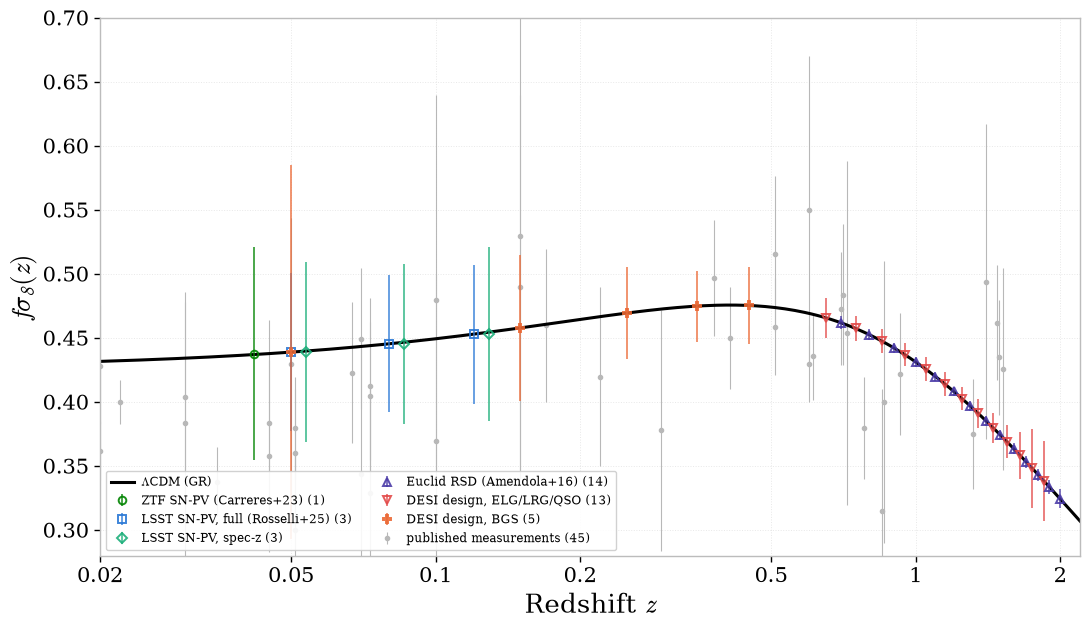

In [5]:
z_grid = np.logspace(np.log10(0.02), np.log10(2.2), 300)

fig, ax = plt.subplots(figsize=(11, 6.4))

# models first, at the bottom of the z-order. With no export copied in this is
# just the fiducial curve -- the forecasts are still the point of the panel.
gr.plotting.plot_theory(ax, "GR", *MODELS, z=z_grid, zorder=1)

# forecast bars: no marker face, drawn on the fiducial curve, never like data
for name, s in SERIES.items():
    gr.plotting.plot_forecasts(ax, s["rows"], gr_model, color=s["color"],
                               marker=s["marker"], ms=5.5, x=dodged(s),
                               label=f"{name} ({len(s['rows'])})")

# published measurements, faint, for context only
meas = gr.load_fsigma8(kind="measurement", drop_derived=True)
meas = meas[meas["z"] > 0.015]
ax.errorbar(meas["z"], meas["value"], yerr=[meas["err_lo"], meas["err_hi"]],
            fmt="o", ms=3, color="0.72", elinewidth=0.8, capsize=0, ls="none",
            zorder=0, label=f"published measurements ({len(meas)})")

ax.set_xscale("log")
gr.style_axes(ax, xlim=(0.02, 2.2), ylim=(0.28, 0.70), scale="linear",
              legend_kw=dict(loc="lower left", fontsize=8.5, ncol=2))
ax.set_xticks([0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0])
ax.set_xticklabels(["0.02", "0.05", "0.1", "0.2", "0.5", "1", "2"])
ax.minorticks_off()
fig.tight_layout()

Two things to read off, and one not to:

* the PV bars at $z \simeq 0.05$ are wide (8-19% of $f\sigma_8$) but they sit where
  the models are most separated;
* the Euclid and DESI bars are narrow (1-3%) but sit where $f(R)$ at
  $|f_{R0}| = 10^{-6}$ and nDGP N5 have nearly converged on $\Lambda$CDM;
* the bars' *positions* carry no information at all — they are on the fiducial
  curve by construction. Only their lengths mean anything.

The three peculiar-velocity configurations forecast the *same* redshift bins, so
their bars are displaced by a few per cent in $\log z$ to keep them apart. The
displacement is cosmetic and applies to the plotted abscissa only; every number
in the rest of the notebook uses the bin's own effective redshift.

Which is why the next panel is the one that answers the question.

## 4. Precision against deviation

Both axes in per cent of $f\sigma_8$: the curves are $|\Delta f\sigma_8|/f\sigma_8$
for each model, the points are each forecast bin's projected
$\sigma_{f\sigma_8}/f\sigma_8$. A point **below** a curve is a bin that separates
that model from $\Lambda$CDM at more than $1\sigma$; the vertical distance is how
many $\sigma$.

no EFTCAMB export: the panel shows forecast precisions only, with nothing to compare them against


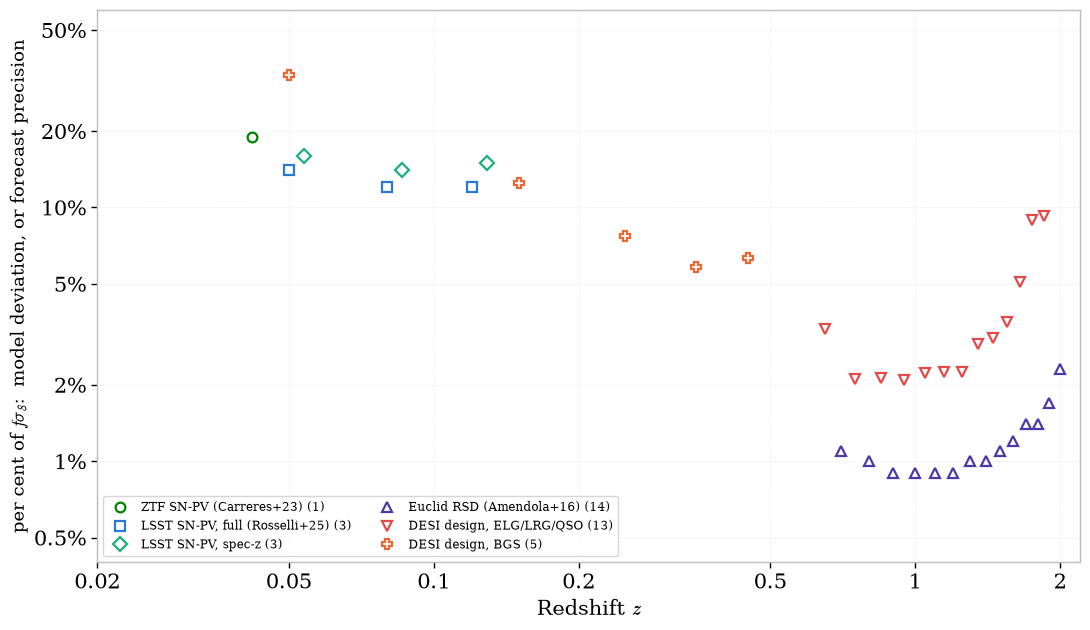

In [6]:
fig, ax = plt.subplots(figsize=(11, 6.4))

if not MODELS:
    print("no EFTCAMB export: the panel shows forecast precisions only, with "
          "nothing to compare them against")

for name in MODELS:
    m = th.get(name)
    dev = 100 * np.abs(m.fsigma8(z_grid) / gr_model.fsigma8(z_grid) - 1)
    ax.plot(z_grid, dev, color=m.style.color, ls=m.style.ls, lw=m.style.lw,
            label=m.label, zorder=1)

for name, s in SERIES.items():
    r = s["rows"]
    ax.plot(dodged(s), 100 * r["frac_err"], ls="none", marker=s["marker"], ms=7,
            mfc="white", mec=s["color"], mew=1.6, zorder=3,
            label=f"{name} ({len(r)})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Redshift $z$", fontsize=15)
ax.set_ylabel(r"per cent of $f\sigma_8$:  model deviation, or forecast precision",
              fontsize=13)
ax.set_xlim(0.02, 2.2)
ax.set_ylim(0.4, 60)
ax.set_xticks([0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0])
ax.set_xticklabels(["0.02", "0.05", "0.1", "0.2", "0.5", "1", "2"])
ax.set_yticks([0.5, 1, 2, 5, 10, 20, 50])
ax.set_yticklabels(["0.5%", "1%", "2%", "5%", "10%", "20%", "50%"])
ax.minorticks_off()
ax.grid(alpha=0.3, lw=0.7, color="0.7", ls=":", which="both")
ax.set_axisbelow(True)
ax.legend(loc="lower left", fontsize=8.5, ncol=2)
fig.tight_layout()

## 5. How many $\sigma$

Per bin, $n_\sigma = |\Delta f\sigma_8| / \sigma_{f\sigma_8}$ with both evaluated at
the bin's effective redshift, and the fiducial $f\sigma_8$ supplying the absolute
scale the fractional forecast error is missing.

In [7]:
import pandas as pd


def n_sigma(rows, model):
    """Per-bin significance of `model` against LCDM, given forecast precisions."""
    m = th.get(model)
    z = rows["z"].to_numpy()
    fid = gr_model.fsigma8(z)
    return np.abs(m.fsigma8(z) - fid) / (rows["frac_err"].to_numpy() * fid)


if MODELS:
    table = pd.DataFrame(
        {name: {model: n_sigma(s["rows"], model).max() for model in MODELS}
         for name, s in SERIES.items()}).T
    table.columns = [th.get(c).label for c in MODELS]
    print("best single bin, in sigma:")
    print(table.round(1).to_string())
else:
    table = pd.DataFrame()
    print("no EFTCAMB export -- nothing to compute a significance against")

no EFTCAMB export -- nothing to compute a significance against


Combining the bins of one programme in quadrature gives a rough total. Rough,
and stated as such: it assumes the bins are independent, which is true for the
disjoint LSST set used here but ignores the shared systematics of a single survey
(peculiar-velocity analyses are dominated by distance-indicator calibration, not
by counting statistics), and it assumes the forecast's own fiducial cosmology is
close enough to the model being tested for the precision to carry over.

In [8]:
if MODELS:
    combined = pd.DataFrame(
        {name: {model: np.sqrt((n_sigma(s["rows"], model) ** 2).sum())
                for model in MODELS}
         for name, s in SERIES.items()}).T
    combined.columns = table.columns
    print("quadrature-combined over bins, in sigma:")
    print(combined.round(1).to_string())
else:
    combined = pd.DataFrame()
    print("no EFTCAMB export -- skipped")

no EFTCAMB export -- skipped


/tmp/ipykernel_1157357/1560782284.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, ncol=3, loc="upper left")


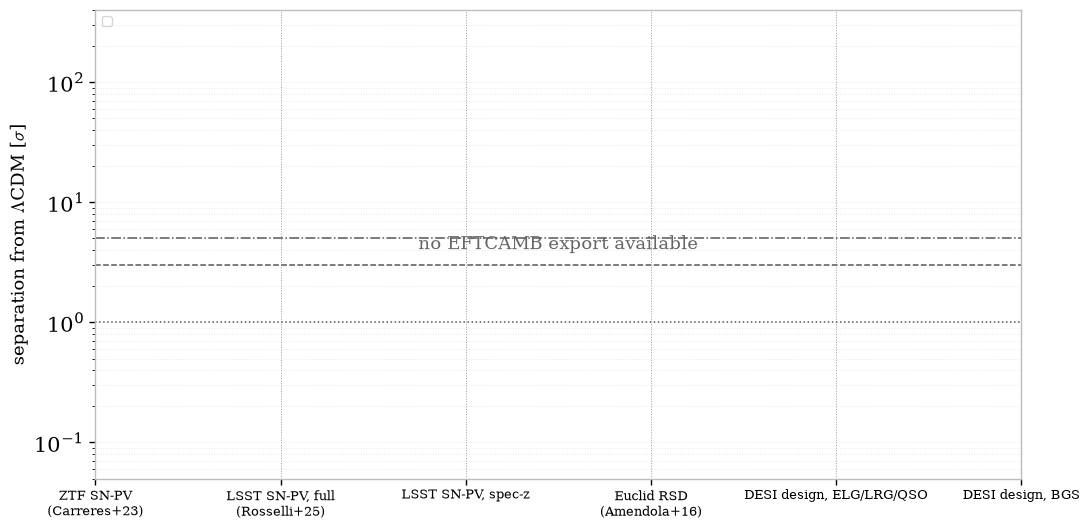

In [9]:
fig, ax = plt.subplots(figsize=(11, 5.4))

x = np.arange(len(SERIES))
if not MODELS:
    ax.text(0.5, 0.5, "no EFTCAMB export available", transform=ax.transAxes,
            ha="center", va="center", fontsize=13, color="0.4")
width = 0.15
for i, model in enumerate(MODELS):
    m = th.get(model)
    ax.bar(x + (i - (len(MODELS) - 1) / 2) * width, combined[m.label], width,
           color=m.style.color, label=m.label,
           edgecolor="0.25", linewidth=0.6)

for level, ls, text in [(1, ":", r"$1\sigma$"), (3, "--", r"$3\sigma$"),
                        (5, "-.", r"$5\sigma$")]:
    ax.axhline(level, color="0.35", lw=1.1, ls=ls)
    ax.annotate(text, (len(SERIES) - 0.45, level * 1.06), fontsize=9, color="0.35")

ax.set_yscale("log")
ax.set_ylim(0.05, 400)
ax.set_xticks(x)
ax.set_xticklabels([n.replace(" (", "\n(") for n in SERIES], fontsize=9)
ax.set_ylabel(r"separation from $\Lambda$CDM [$\sigma$]", fontsize=13)
ax.grid(alpha=0.3, lw=0.7, color="0.7", ls=":", axis="y", which="both")
ax.set_axisbelow(True)
ax.legend(fontsize=9, ncol=3, loc="upper left")
fig.tight_layout()

## 6. Where each survey is strongest

The same numbers, resolved in redshift rather than summed: which bin of which
programme carries the separation. This is the plot that says *why* a
peculiar-velocity survey and a spectroscopic survey are not substitutes — they
are strongest against different models.

/tmp/ipykernel_1157357/3370421519.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[-1].legend(fontsize=7.5, loc="lower left")


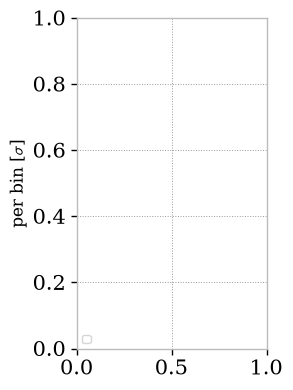

In [10]:
fig, axes = plt.subplots(1, max(len(MODELS), 1),
                         figsize=(3.1 * max(len(MODELS), 1), 4.0), sharey=True,
                         squeeze=False)
axes = axes[0]

for ax, model in zip(axes, MODELS):
    m = th.get(model)
    for name, s in SERIES.items():
        r = s["rows"]
        ax.plot(dodged(s), n_sigma(r, model), ls="none", marker=s["marker"], ms=6,
                mfc="white", mec=s["color"], mew=1.5, label=name)
    ax.axhline(1, color="0.35", lw=1.0, ls=":")
    ax.axhline(3, color="0.35", lw=1.0, ls="--")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(0.02, 200)
    ax.set_xlim(0.02, 2.5)
    ax.set_title(m.label, fontsize=10, color=m.style.color)
    ax.set_xlabel("Redshift $z$")
    ax.grid(alpha=0.3, lw=0.7, color="0.7", ls=":", which="both")
    ax.set_axisbelow(True)
axes[0].set_ylabel(r"per bin [$\sigma$]", fontsize=12)
axes[-1].legend(fontsize=7.5, loc="lower left")
fig.tight_layout()

## 7. What would be detectable

Turning it around: for each programme, the weakest model it still separates from
$\Lambda$CDM at $3\sigma$ — the bound each forecast implies, in the parameter the
literature quotes ($|f_{R0}|$).

This needs a *family* of models, not the handful in the registry: one EFTCAMB run
per scanned parameter value. Rather than approximate them here, the scan is built
from exports — `eftcamb_theory.ipynb` §6 already scans $B_0$, and
`growth-review-eftcamb-export --fR0 …` writes one table per $f_{R0}$. The cell
below uses whatever designer-$f(R)$ exports exist and says how many it found.

In [11]:
import re

# Designer f(R) exports, weak -> strong by the |f_R0| the exporter wrote into the
# model name (fR_fR0_<value>). One EFTCAMB run per tier -- nothing interpolated.
FR0_EXPORTS = {}
for name in MODELS:
    match = re.search(r"fR_fR0_([0-9.e+-]+)", name)
    if match:
        FR0_EXPORTS[float(match.group(1))] = th.get(name)
FR0_EXPORTS = dict(sorted(FR0_EXPORTS.items()))          # ascending |f_R0|

print(f"{len(FR0_EXPORTS)} designer-f(R) export(s):",
      ", ".join(f"{v:.0e}" for v in FR0_EXPORTS) or "none")


def threshold(rows, models, target=3.0):
    """The weakest exported parameter a programme still separates at `target`.

    The grid runs weak -> strong and n_sigma is monotone along it, so the first
    passing value is the threshold. Returns (value, n_sigma, hit_edge); hit_edge
    marks the case where only the strongest exported model passes, i.e. the real
    threshold lies outside what was run, and the number bounds the scan rather
    than the survey.
    """
    values = list(models)
    for i, v in enumerate(values):
        n = np.sqrt((n_sigma(rows, models[v]) ** 2).sum())
        if n >= target:
            return v, n, i == len(values) - 1
    return None, None, False


if FR0_EXPORTS:
    print(f"\n{'programme':32} {'|f_R0| detected at 3 sigma':>26}")
    for name, s in SERIES.items():
        fr, n_fr, edge = threshold(s["rows"], FR0_EXPORTS)
        txt = "none exported" if fr is None else (
            f"> {fr:.1e}" + (" (scan edge)" if edge else ""))
        print(f"{name:32} {txt:>26}")
else:
    print("\nNothing to scan. Export a few designer-f(R) tiers first:")
    print("  growth-review-eftcamb-export --fR0 -1e-4 -3e-5 -1e-5 -3e-6 -1e-6")

0 designer-f(R) export(s): none

Nothing to scan. Export a few designer-f(R) tiers first:
  growth-review-eftcamb-export --fR0 -1e-4 -3e-5 -1e-5 -3e-6 -1e-6


Read the column as "this programme separates any $|f_{R0}|$ **larger** than this
from $\Lambda$CDM at $3\sigma$", with the resolution of the exported grid — a
threshold quoted between two scanned tiers means running more.

## 8. Caveats

These matter more than the numbers above, because the numbers are only as good as
the assumptions they inherit.

1. **Forecasts are precisions, not measurements.** Nothing here says a model is
   ruled out; it says how well a survey would distinguish it if $\Lambda$CDM is
   right and the forecast is achieved.
2. **The fiducial cosmology is $\Lambda$CDM throughout.** Each forecast's own
   fiducial differs slightly from Planck 2018, and a fractional precision derived
   under one fiducial is applied here to another. Fine at the few-per-cent level
   of this comparison, not fine if a number is quoted to two digits.
3. **Euclid's quoted error is fractional on $f$**, not on $f\sigma_8$
   (Amendola et al. 2016, Table 4); it is used here as a fractional error on
   $f\sigma_8$, which ignores the $\sigma_8$ contribution and so slightly
   *overstates* Euclid's reach.
4. **DESI numbers are the 2016 design forecast** at $k_{\rm max} = 0.1\,h/$Mpc
   (`dfs0.1`); the achieved DR1 full-shape precision is in the measurement
   compilation and is the fairer thing to compare a DR2/DR5 projection against.
5. **LSST bins are nested in the source table.** Only the disjoint set is
   combined here; the widest bin is shown in the first panel.
6. **$f(R)$ growth is scale dependent.** EFTCAMB's $f\sigma_8$ is one number per
   redshift, built from $\sigma_8$, so it is an effective quantity at
   $8\,h^{-1}$Mpc (`eftcamb_theory.ipynb`, §6b, quantifies the spread in
   $f(k,z)$). A PV survey measures large, quasi-linear scales and an RSD
   full-shape fit smaller ones, so a strict comparison would need each survey's
   own effective $k$.
7. **The quadrature combination assumes independent bins and no shared
   systematics.** For PV surveys the distance-indicator calibration is
   correlated across bins and usually dominates, so the combined $\sigma$ values
   are upper bounds on what the programme really delivers.
8. **Whether a model's expansion history is $\Lambda$CDM's decides whether BAO
   and supernova distances help.** Designer $f(R)$ preserves it by construction,
   K-mouflage and the scaling cubic Galileon to better than 1%
   (`eftcamb_theory.ipynb`, §9-10), while the $w_0w_a$ and quintessence entries do
   not — against those, distances would do most of the work and this accounting
   would look entirely different.

9. **nDGP is absent.** It has no EFTCAMB mapping, and the covariant embedding of
   its decoupling limit is ghost- or gradient-unstable on both branches once
   coupled to gravity. The source notebook treats it with a standalone
   quasi-static calculation; that is not reproduced here, so the figure has no
   nDGP curve rather than an approximation of one.

In [12]:
# The caveats each model carries in the registry, printed rather than trusted to
# memory: they are the same strings the figure captions draw on.
for name in (MODELS[:1] + MODELS[-1:]) or ["GR"]:
    m = th.get(name)
    print(f"{m.label}  [{m.source}]")
    for c in m.caveats:
        print(f"  - {c}")
    print()

$\Lambda$CDM (GR)  []

